In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
import netCDF4  
import time
import utils as u

import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *

In [4]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]
domain = 'MARFed'

In [5]:
# Selection des données montagne vs plaine
alti_thrs = 1500

### MAR

In [6]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

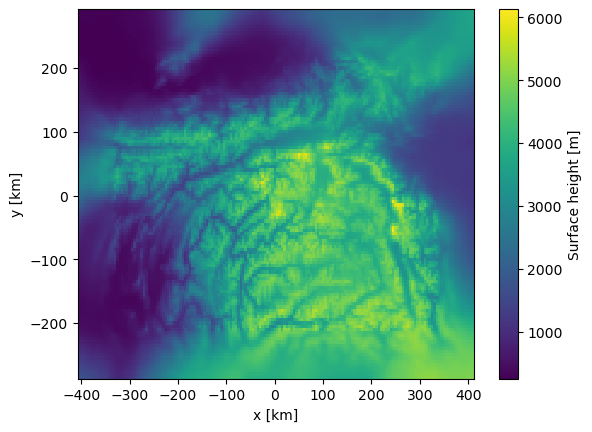

In [7]:
ds_grF.SH.plot()

In [8]:
#MAR dataset
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRf/spin2/work/monthly/'
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_GRf_2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ZTQLEV=0).TTZ.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

dsF = dsF.sel(time=slice("2000-01-01", "2020-12-31"))

model1='MAR'
res1=str('5kmx5km')

In [9]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


In [10]:
# Enlever k pixels sur les contours
k=15
dsF=dsF.isel(X=slice(k, -k), Y=slice(k, -k))
ds_grF=ds_grF.isel(x=slice(k, -k), y=slice(k, -k))

lat_min=ds_grF.LAT.values.min()
lat_max=ds_grF.LAT.values.max()

lon_min=ds_grF.LON.values.min()
lon_max=ds_grF.LON.values.max()

# latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
# lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

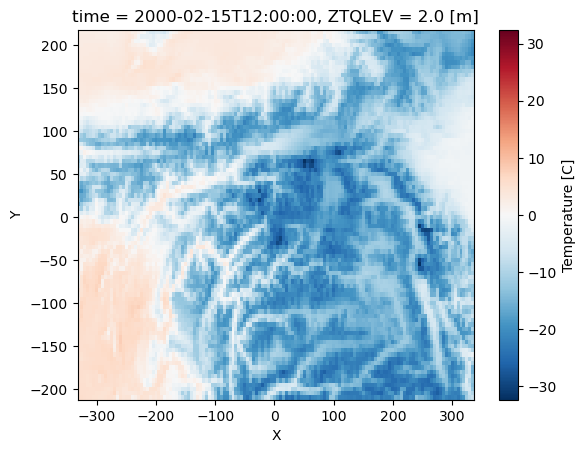

In [11]:
dsF.isel(time=1).plot()

# WORK in PROGRESS : comment extraire les données MAR pour SH > 1000 ?

In [12]:
ds_grF.SH>1000

<xarray.DataArray 'SH' (y: 86, x: 134)>
array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True]])
Coordinates:
  * x        (x) float32 -330.0 -325.0 -320.0 -315.0 ... 320.0 325.0 330.0 335.0
  * y        (y) float32 -210.0 -205.0 -200.0 -195.0 ... 200.0 205.0 210.0 215.0

In [ ]:
### Ca plante !!!
masked_dsF = dsF.where(ds_grF.SH > 1000, drop=True)

### ERA5

In [13]:
folder_era5='/bettik/PROJECTS/pr-regional-climate/fainx/era5/'

tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
tmp_era5 = tmp_era5.sel(time=slice("2000-01-01", "2020-12-31"))
tmp_era5 = tmp_era5.where((tmp_era5.lat >= lat_min) & (tmp_era5.lat <= lat_max), drop=True)
tmp_era5 = tmp_era5.where((tmp_era5.lon >= lon_min) & (tmp_era5.lon <= lon_max), drop=True)

model2='ERA5'
res2=str('31kmx31km')

(25, 49)


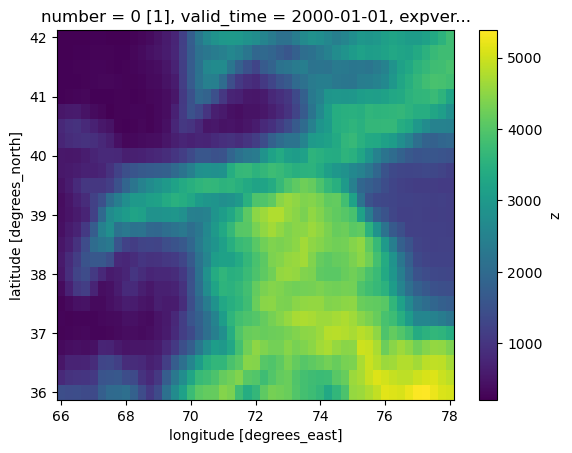

In [14]:
# ERA5 orography
orog_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5=orog_era5.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5.shape)
orog_era5[:,:].plot()

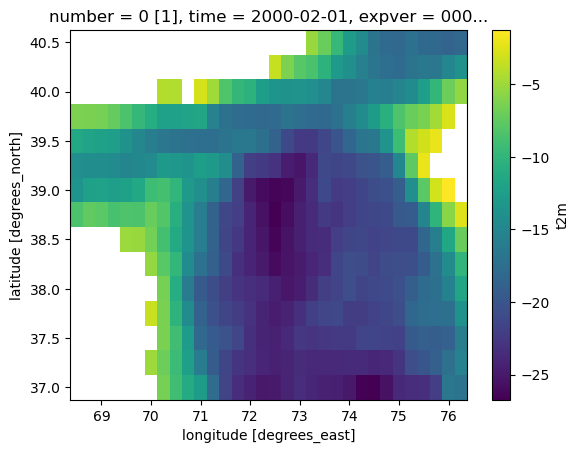

In [15]:
# Selection des données montagne vs plaine
orog_era5_on_tmp_grid = orog_era5.interp(
    lat=tmp_era5.lat,
    lon=tmp_era5.lon,
    method="linear"  
)

tmp_era5_high = tmp_era5.where(orog_era5_on_tmp_grid > alti_thrs)
tmp_era5_high.isel(time=1).plot()

### ERA5-land

In [16]:
folder_era5land='/bettik/PROJECTS/pr-regional-climate/fainx/era5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

tmp_era5land = tmp_era5land.sel(time=slice("2000-01-01", "2020-12-31"))
tmp_era5land = tmp_era5land.where((tmp_era5land.lat >= lat_min) & (tmp_era5land.lat <= lat_max), drop=True)
tmp_era5land = tmp_era5land.where((tmp_era5land.lon >= lon_min) & (tmp_era5land.lon <= lon_max), drop=True)

model3='ERA5-Land'
res3=str('0.1°x0.1°')

(61, 121)


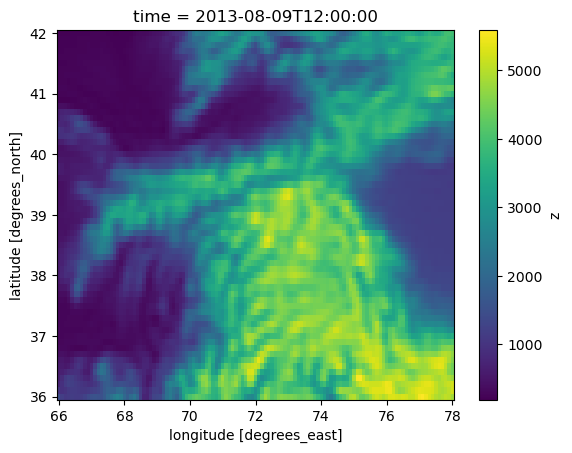

In [17]:
# ERA5-land orography
orog_era5land= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
orog_era5land=orog_era5land.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5land.shape)
orog_era5land[:,:].plot()

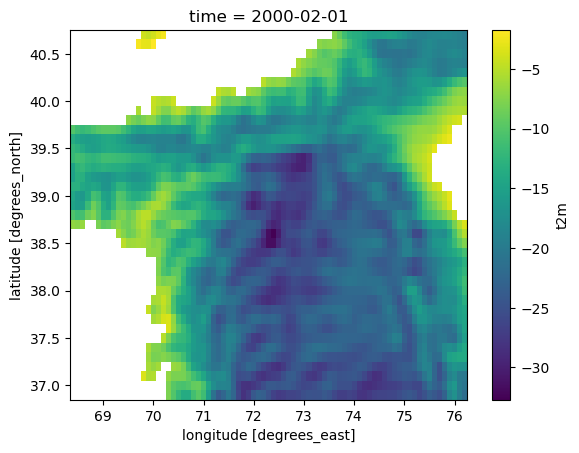

In [18]:
# Selection des données montagne vs plaine
orog_era5land_interp = orog_era5land.interp(
    lat=tmp_era5land.lat,
    lon=tmp_era5land.lon,
    method="linear"  
)

tmp_era5land_high = tmp_era5land.where(orog_era5land_interp > alti_thrs)
tmp_era5land_high
tmp_era5land_high.isel(time=1).plot()

### CRU

In [28]:
tmp_cru

<xarray.DataArray 'tmp' (time: 24, lat: 7, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 37.25 37.75 38.25 38.75 39.25 39.75 40.25
  * time     (time) datetime64[ns] 2000-01-16 2000-02-15 ... 2020-12-16
Attributes:
    long_name:                   near-surface temperature
    units:                       degrees Celsius
    correlation_decay_distance:  1200.0

In [29]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').tmp.load()
tmp_cru = tmp_cru.where((tmp_cru.lat >= lat_min) & (tmp_cru.lat <= lat_max), drop=True)
tmp_cru = tmp_cru.where((tmp_cru.lon >= lon_min) & (tmp_cru.lon <= lon_max), drop=True)

tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

model4='CRU'
res4=str('0.5°x0.5°')

/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to d

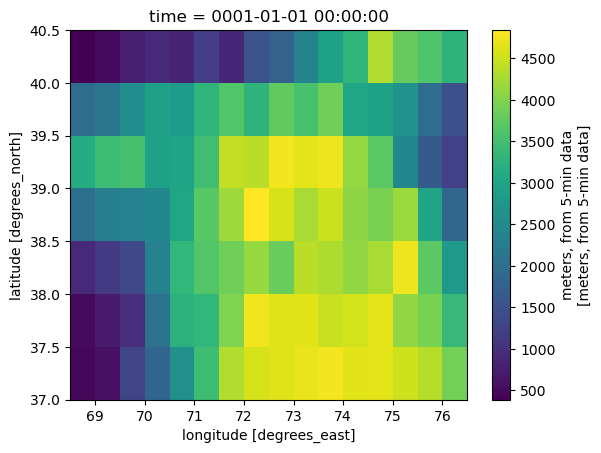

In [30]:
# JSIO orography for CRU
orog_jisao = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/jisao/' + 'jisao_elev.0.25-deg.nc').isel(time=0)

orog_cru=orog_jisao.interp(lat=tmp_cru.lat,lon=tmp_cru.lon)
orog_cru.data.plot()

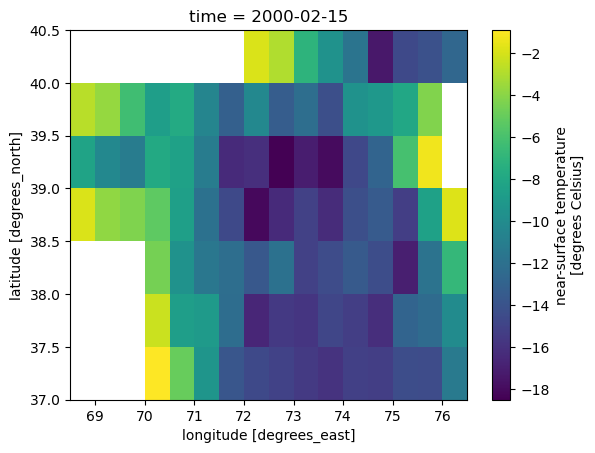

In [31]:
# Selection des données montagne vs plaine
orog_cru_interp = orog_cru.interp(
    lat=tmp_cru.lat,
    lon=tmp_cru.lon,
    method="linear"  
)

tmp_cru_high = tmp_cru.where(orog_cru_interp > alti_thrs)
tmp_cru_high
tmp_cru_high.data.isel(time=1).plot()

### HARv2

In [33]:
folder_HARv2='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
tmp_HARv2 = xr.open_mfdataset(folder_HARv2 + 'HARv2_mon_d10km_d_2d_t2_1980-2023.nc').t2.load()-273.15
tmp_HARv2= tmp_HARv2.sel(time=slice("2000-01-01", "2020-12-31"))

def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
      #  print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

tmp_HARv2=xy_sel_dom(tmp_HARv2,domain)
# tmp_HARv2=tmp_HARv2.sel(lat=latlim_grF,lon=lonlim_grF)

model5='HARv2'
res5=str('10kmx10km')

In [34]:
toto = xr.open_mfdataset(folder_HARv2 + 'HARv2_mon_d10km_d_2d_t2_1980-2023.nc')
toto

<xarray.Dataset>
Dimensions:      (time: 528, bnds: 2, south_north: 252, west_east: 381)
Coordinates:
  * time         (time) datetime64[ns] 1980-01-16 1980-02-15 ... 2023-12-16
    lon          (south_north, west_east) float32 dask.array<chunksize=(252, 381), meta=np.ndarray>
    lat          (south_north, west_east) float32 dask.array<chunksize=(252, 381), meta=np.ndarray>
  * west_east    (west_east) float32 -1.675e+06 -1.665e+06 ... 2.125e+06
  * south_north  (south_north) float32 -7.45e+05 -7.35e+05 ... 1.765e+06
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds) datetime64[ns] dask.array<chunksize=(528, 2), meta=np.ndarray>
    t2           (time, south_north, west_east) float32 dask.array<chunksize=(528, 252, 381), meta=np.ndarray>
Attributes: (12/38)
    CDI:                  Climate Data Interface version 2.4.4 (https://mpime...
    Conventions:          CF-1.6
    TITLE:                HAR v2 d10km
    DATA_NOTES:           File generated with the output of successive model ...
    WRF_VERSION:           OUTPUT FROM WRF V4.1 MODEL
    CREATED_BY:           Xun Wang - xun.wang@tu-berlin.de
    ...                   ...
    GRID_Y01:             1765001.0
    GRID_NX:              381
    GRID_NY:              252
    history:              Tue May 06 14:15:54 2025: cdo monmean HARv2_day_d10...
    frequency:            mon
    CDO:                  Climate Data Operators version 2.4.4 (https://mpime...

# WORK IN PROGRESS : comment selectionner les données HARv2 en altitude?

In [35]:
modelList=[model1,model2,model3,model4,model5]
resList=[res1,res2,res3,res4,res5]
print(modelList)
print(resList)

['MAR', 'ERA5', 'ERA5-Land', 'CRU', 'HARv2']
['5kmx5km', '31kmx31km', '0.1°x0.1°', '0.5°x0.5°', '10kmx10km']


## All altitudes included

In [36]:
dsList=[dsF,tmp_era5, tmp_era5land, tmp_cru, tmp_HARv2]

In [37]:
avgList=[]
for i,elem in enumerate(dsList):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [4]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='west_east').mean(dim='south_north')
    avgList.append(avg0)

0
MAR 5kmx5km
1
ERA5 31kmx31km
2
ERA5-Land 0.1°x0.1°
3
CRU 0.5°x0.5°
4
HARv2 10kmx10km


In [38]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

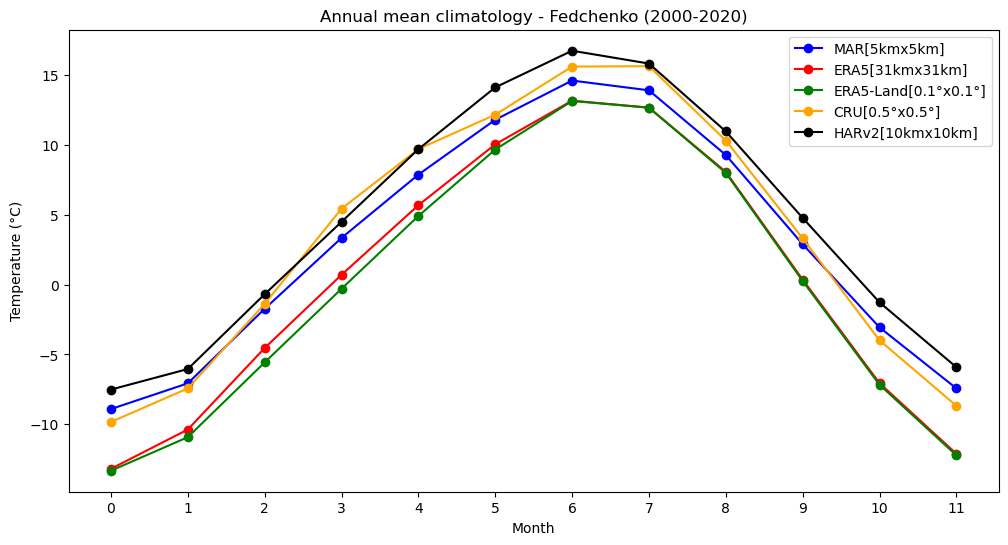

In [39]:
title="Annual mean climatology - Fedchenko (2000-2020)"

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')
ax.plot(xmonths, annualCycleList[4], 'black',linestyle='-',marker='o',label=modelList[4]+'['+ resList[4]+']')


ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig('AnnualClimato_Fed.png',format='png')
plt.show()

## Only altitudes > 1500m included

In [42]:
#en attendant de bien calculer dsF_high.. 
dsF_high = dsF
tmp_HARv2_high = tmp_HARv2

In [43]:
dsList_high=[dsF_high,tmp_era5_high, tmp_era5land_high, tmp_cru_high, tmp_HARv2_high]

In [44]:
avgList=[]
for i,elem in enumerate(dsList_high):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [4]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='west_east').mean(dim='south_north')
    avgList.append(avg0)

0
MAR 5kmx5km
1
ERA5 31kmx31km
2
ERA5-Land 0.1°x0.1°
3
CRU 0.5°x0.5°
4
HARv2 10kmx10km


In [45]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

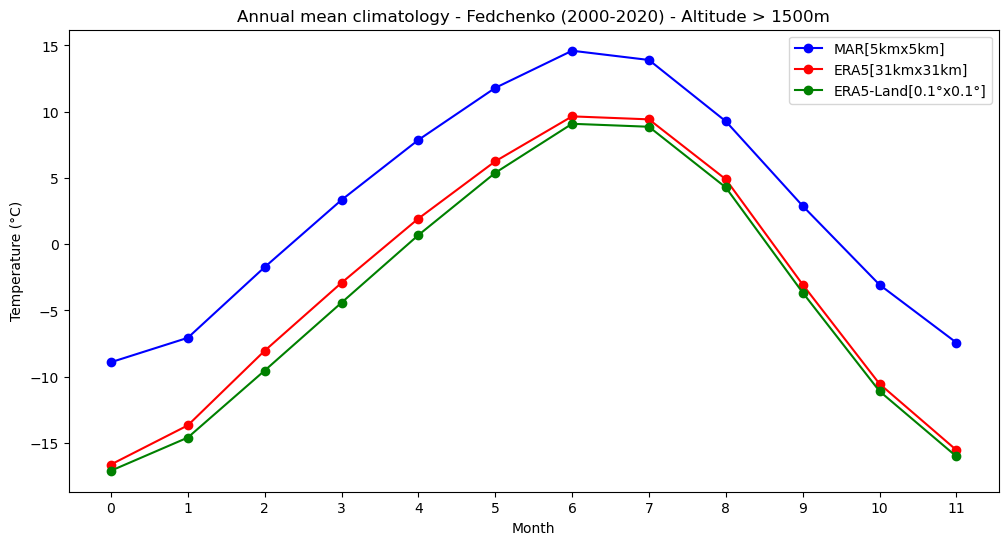

In [47]:
title="Annual mean climatology - Fedchenko (2000-2020) - Altitude > 1500m"

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
# ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')
# ax.plot(xmonths, annualCycleList[4], 'black',linestyle='-',marker='o',label=modelList[4]+'['+ resList[4]+']')


ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig('AnnualClimato_Fed_high.png',format='png')
plt.show()